In [92]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import time
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

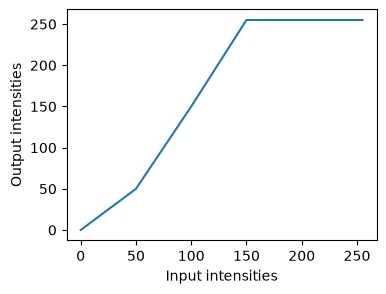

In [93]:
input_intensity=[0,50,100,150,255]
output_intensity=[0,50,150,255,255]
plt.figure(figsize=(4,3))
plt.plot(input_intensity, output_intensity)
plt.xlabel("Input intensities")
plt.ylabel("Output intensities")
plt.show()

In [ ]:
#Defining the function
def intensity_transform(pix,b1,b2,b3,b4,b5):
    if b1<=pix<=b2:
        pix_out=pix
    elif b2<pix<=b3:
        pix_out=50+((pix-b2)*(150-50)/(100-50))
    elif b3<pix<=b4:
            pix_out=150+((pix-b3)*(255-150)/(150-100))
    elif b4<pix<=b5:
            pix_out=255
    return pix_out        

In [190]:
#vectorizing the function
vec_trans=np.vectorize(intensity_transform)
#reading the image as a grayscle image
img=cv.imread("image_1.png",cv.IMREAD_GRAYSCALE)
#applied the vectorized transformation on image
transformed_image=vec_trans(img,0,50,100,150,255)

(np.float64(-0.5), np.float64(581.5), np.float64(657.5), np.float64(-0.5))

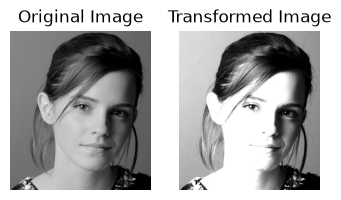

In [99]:
#plotting
plt.figure(figsize=(4,3))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(transformed_image, cmap="gray")
plt.title("Transformed Image")
plt.axis("off")

Question 2

In [8]:
img_2=cv.imread('image_2.png',cv.IMREAD_GRAYSCALE)

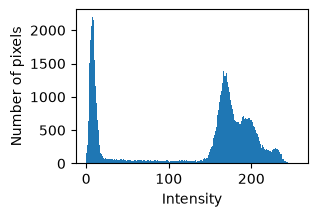

In [204]:
#first look at the intensity distrrbution
plt.figure(figsize=(3,2))
plt.hist(img_2.ravel(), bins=256, range=[0,256])
plt.xlabel("Intensity")
plt.ylabel("Number of pixels")
plt.show()

In [191]:
def filter_matter(pix, t1, t2, t3):
    if pix < t1:
        pix_out = 0
    elif pix < t2:
        pix_out = 100
    elif pix < t3:
        pix_out = 200
    else:
        pix_out = 255
    return pix_out
vec_fillter=np.vectorize(filter_matter)
filtered_image = vec_fillter(img_2, 150, 180, 210)    

(np.float64(-0.5), np.float64(251.5), np.float64(300.5), np.float64(-0.5))

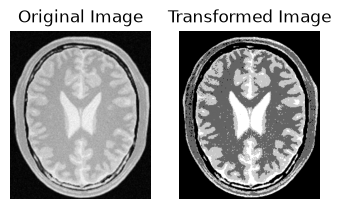

In [192]:
#plotting
plt.figure(figsize=(4,3))
plt.subplot(1, 2, 1)
plt.imshow(img_2, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(filtered_image, cmap="gray")
plt.title("Transformed Image")
plt.axis("off")

Question 3


In [ ]:
#Read the mage
img_3=cv.imread("image_3.png")
#convert to LAB format
img_LAB=cv.cvtColor(img_3, cv.COLOR_BGR2LAB)
L,a,b= cv.split(img_LAB)
#normalize
L_norm= L/255.0
#Gamma correction
gamma=0.5
L_corrected=np.power(L_norm,gamma)
#convert back to 0-255
L_corrected=(L_corrected*255).astype(np.uint8)
Lab_merged=cv.merge([L_corrected,a,b,])
#BGR
corrected_img=cv.cvtColor(Lab_merged,cv.COLOR_LAB2BGR)

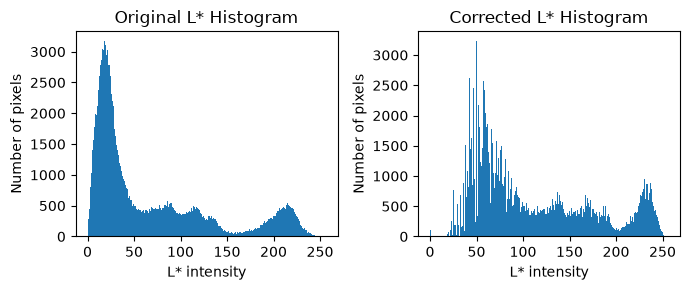

In [111]:
plt.figure(figsize=(7,3))
plt.subplot(1, 2, 1)
plt.hist(img_3.ravel(), bins=256, range=[0, 256])
plt.title("Original L* Histogram")
plt.xlabel("L* intensity")
plt.ylabel("Number of pixels")
plt.subplot(1, 2, 2)
plt.hist(corrected_img.ravel(), bins=256, range=[0, 256])
plt.title("Corrected L* Histogram")
plt.xlabel("L* intensity")
plt.ylabel("Number of pixels")
plt.tight_layout()
plt.show()

Question 4

In [201]:
#read the image
img_4=cv.imread('image_4.png')
#convert to BGR to HSV
hsv=cv.cvtColor(img_4,cv.COLOR_BGR2HSV)
#split
H,S,V=cv.split(hsv)

In [202]:
#function
def transformation(x, a, sigma):
    return np.minimum(
        x + a * 128 * np.exp(-((x - 128)**2) / (2 * sigma**2)),
        255
    )

C:\Users\Praveen\AppData\Local\Temp\ipykernel_14316\453392140.py:4: RuntimeWarning: overflow encountered in scalar subtract
  x + a * 128 * np.exp(-((x - 128)**2) / (2 * sigma**2)),
C:\Users\Praveen\AppData\Local\Temp\ipykernel_14316\453392140.py:4: RuntimeWarning: overflow encountered in scalar negative
  x + a * 128 * np.exp(-((x - 128)**2) / (2 * sigma**2)),


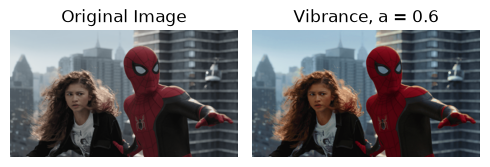

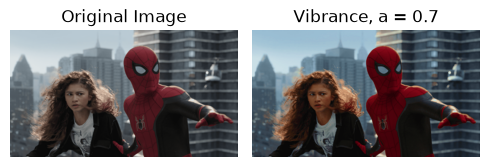

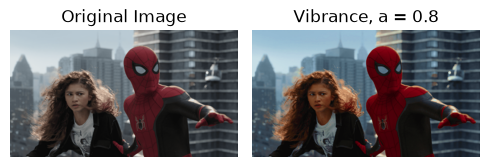

In [205]:
vec_vibrance=np.vectorize(transformation)
a_values = np.arange(0.6, 0.8, 0.1)
for a in a_values:

    S_transformed = vec_vibrance(S, a, 70)
    S_transformed = S_transformed.astype(np.uint8)

    # Merge H, transformed S, and V
    hsv_merged = cv.merge([H, S_transformed, V])

    # Convert HSV → BGR
    result = cv.cvtColor(hsv_merged, cv.COLOR_HSV2BGR)

    # Side-by-side display
    plt.figure(figsize=(5,3))

    # Original
    plt.subplot(1, 2, 1)
    plt.imshow(cv.cvtColor(img_4, cv.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis('off')

    # Transformed
    plt.subplot(1, 2, 2)
    plt.imshow(cv.cvtColor(result, cv.COLOR_BGR2RGB))
    plt.title(f"Vibrance, a = {a:.1f}")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

0.7 a value is much prefered

Question 5

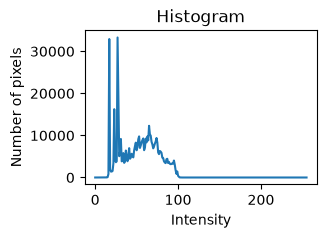

In [210]:
img_5=cv.imread('image_5.png')
hist = np.zeros(256)
for pixel in img_5.flatten():
    hist[pixel] += 1

plt.figure(figsize=(3,2))
plt.plot(hist)
plt.title("Histogram")
plt.xlabel("Intensity")
plt.ylabel("Number of pixels")
plt.show()

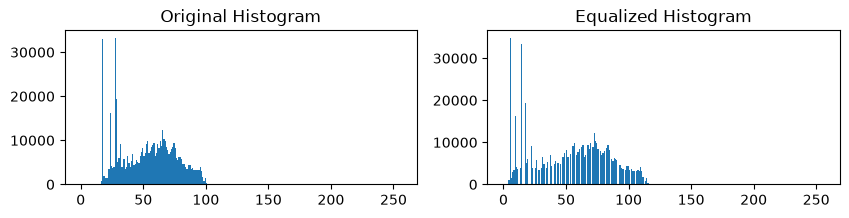

In [198]:
#calculating the CDF
cdf=np.cumsum(hist)
cdf_min = cdf[cdf > 0].min()
cdf_normalized = (cdf - cdf_min) / (cdf[-1] - cdf_min) * 255
equalized=cdf_normalized[img_5].astype(np.uint8)

plt.figure(figsize=(10,2))
plt.subplot(1,2,1)
plt.hist(img_5.ravel(), bins=256, range=(0,256))
plt.title("Original Histogram")
plt.subplot(1,2,2)
plt.hist(equalized.ravel(), bins=256, range=(0,256))
plt.title("Equalized Histogram")
plt.show()

Question 6

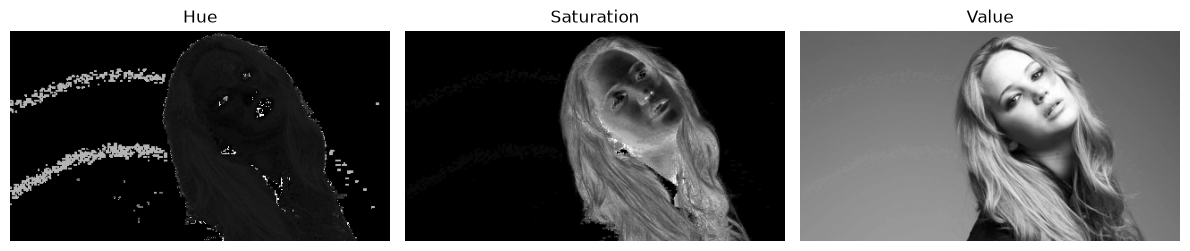

In [207]:
img_6=cv.imread('img_6.png')
hsv=cv.cvtColor(img_6,cv.COLOR_BGR2HSV)
H,S,V=cv.split(hsv)
# Display the three planes in grayscale
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(H, cmap='gray')
plt.title("Hue")
plt.axis("off")
plt.subplot(1, 3, 2)
plt.imshow(S, cmap='gray')
plt.title("Saturation")
plt.axis("off")
plt.subplot(1, 3, 3)
plt.imshow(V, cmap='gray')
plt.title("Value")
plt.axis("off")
plt.tight_layout()
plt.show()

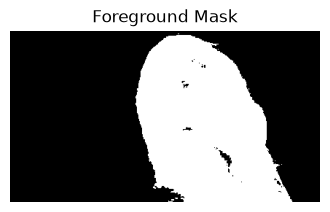

In [208]:
threshold = 15
_, mask_6 = cv.threshold(S, threshold, 255, cv.THRESH_BINARY)
plt.figure(figsize=(4,3))
plt.imshow(mask_6, cmap='gray')
plt.title("Foreground Mask")
plt.axis('off')
plt.show()

In [147]:

foreground=cv.bitwise_and(img_6,img_6,mask=mask_6)

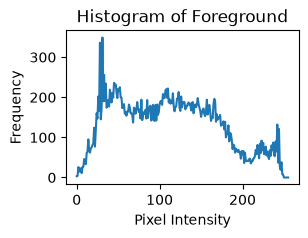

In [151]:
gray_foreground = cv.cvtColor(foreground, cv.COLOR_BGR2GRAY)
hist = cv.calcHist(
    [gray_foreground],
    [0],
    mask_6,
    [256],
    [0, 256]
)
plt.figure(figsize=(3,2))
plt.plot(hist)
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.title("Histogram of Foreground")
plt.show()

In [ ]:
# Histogram of foreground
fg_pixels = gray_foreground[mask_6 > 0]
L = 256
MN = len(fg_pixels)
hist = np.bincount(fg_pixels, minlength=L)
# (d) Cumulative sum of histogram
cdf_foreground = np.cumsum(hist)
# Histogram equalization transformation
T = ((L - 1) / MN) * cdf_foreground
# Round and convert to uint8
T = np.round(T).astype(np.uint8)
# Apply transformation only to foreground
equalized_fg = gray_foreground.copy()
equalized_fg[mask_6 > 0] = T[gray_foreground[mask_6 > 0]]
# Extract background from original grayscale image
gray = cv.cvtColor(img_6, cv.COLOR_BGR2GRAY)
background = gray.copy()
background[mask_6 > 0] = 0
# Add equalized foreground and original background
result = background + equalized_fg * (mask_6 > 0)

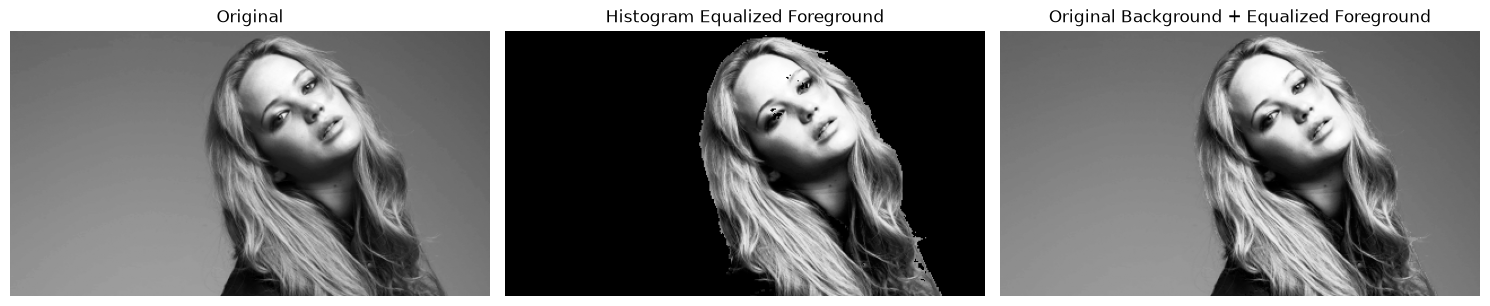

In [193]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(gray, cmap='gray')
plt.title("Original")
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(equalized_fg, cmap='gray')
plt.title("Histogram Equalized Foreground")
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(result, cmap='gray')
plt.title("Original Background + Equalized Foreground")
plt.axis('off')
plt.tight_layout()
plt.show()

Question 7


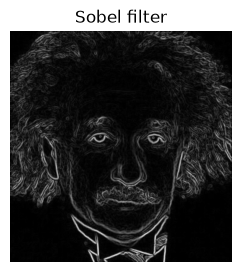

In [194]:
img_7 = cv.imread('image_7.png', cv.IMREAD_GRAYSCALE)
Sx = np.array([[-1, 0, 1],
               [-2, 0, 2],
               [-1, 0, 1]], dtype=np.float32)

Sy = np.array([[-1, -2, -1],
               [ 0,  0,  0],
               [ 1,  2,  1]], dtype=np.float32)

Gx = cv.filter2D(img_7, cv.CV_64F, Sx)
Gy = cv.filter2D(img_7, cv.CV_64F, Sy)
grad_mag = np.sqrt(Gx**2 + Gy**2)
grad_mag = np.uint8(255 * grad_mag / grad_mag.max())

plt.figure(figsize=(4,3))
plt.imshow(grad_mag, cmap='gray')
plt.title("Sobel filter")
plt.axis('off')
plt.show()

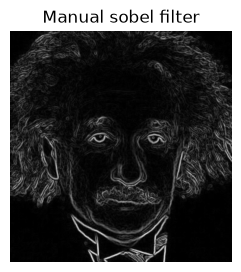

In [162]:
def sobel_manual(img):
    img = img.astype(np.float64)
    H, W = img.shape
    padded = np.pad(img, 1, mode='edge')  # zero/edge padding, your choice

    Sx = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]])
    Sy = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]])

    Gx = np.zeros((H, W))
    Gy = np.zeros((H, W))

    for i in range(H):
        for j in range(W):
            region = padded[i:i+3, j:j+3]
            Gx[i, j] = np.sum(region * Sx)
            Gy[i, j] = np.sum(region * Sy)

    mag = np.sqrt(Gx**2 + Gy**2)
    mag = np.uint8(255 * mag / mag.max())
    return mag, Gx, Gy

grad_mag_manual, Gx, Gy = sobel_manual(img_7)
plt.figure(figsize=(4,3))
plt.imshow(grad_mag_manual, cmap='gray')
plt.title("Manual sobel filter")
plt.axis('off')
plt.show()

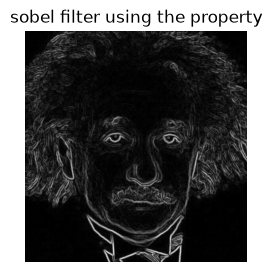

In [164]:
smooth = np.array([1, 2, 1], dtype=np.float32)   # vertical (column)
deriv  = np.array([1, 0, -1], dtype=np.float32)  # horizontal (row)
# Gx = smooth (vertical) then deriv (horizontal)
temp = cv.filter2D(img_7, cv.CV_64F, smooth.reshape(3, 1))
Gx_sep = cv.filter2D(temp, cv.CV_64F, deriv.reshape(1, 3))
# Gy = deriv (vertical) then smooth (horizontal) — swap roles
temp2 = cv.filter2D(img_7, cv.CV_64F, deriv.reshape(3, 1))
Gy_sep = cv.filter2D(temp2, cv.CV_64F, smooth.reshape(1, 3))
grad_mag_sep = np.sqrt(Gx_sep**2 + Gy_sep**2)
grad_mag_sep = np.uint8(255 * grad_mag_sep / grad_mag_sep.max())

plt.figure(figsize=(4,3))
plt.imshow(grad_mag_sep, cmap='gray')
plt.title("sobel filter using the property")
plt.axis('off')
plt.show()

Question 8

In [ ]:
# Zoom function
# interpolation = "nearest" or "bilinear"
def zoom_image(img, scale, interpolation="nearest"):
    h, w = img.shape[:2]

    new_h = int(h * scale)
    new_w = int(w * scale)

    # Handle grayscale and color images
    if len(img.shape) == 2:
        output = np.zeros((new_h, new_w), dtype=img.dtype)
    else:
        output = np.zeros((new_h, new_w, img.shape[2]), dtype=img.dtype)

    for y in range(new_h):
        # Corresponding position in original image
        src_y = y / scale
        if interpolation == "nearest":
            y_nearest = int(round(src_y))
            y_nearest = min(y_nearest, h - 1)
            for x in range(new_w):
                src_x = x / scale
                x_nearest = int(round(src_x))
                x_nearest = min(x_nearest, w - 1)
                output[y, x] = img[y_nearest, x_nearest]
        elif interpolation == "bilinear":
            y0 = int(np.floor(src_y))
            y1 = min(y0 + 1, h - 1)
            dy = src_y - y0
            for x in range(new_w):
                src_x = x / scale
                x0 = int(np.floor(src_x))
                x1 = min(x0 + 1, w - 1)
                dx = src_x - x0
                # Four neighboring pixels
                p00 = img[y0, x0]
                p01 = img[y0, x1]
                p10 = img[y1, x0]
                p11 = img[y1, x1]
                # Bilinear interpolation
                value = (
                    p00 * (1 - dx) * (1 - dy)
                    + p01 * dx * (1 - dy)
                    + p10 * (1 - dx) * dy
                    + p11 * dx * dy
                )
                output[y, x] = np.clip(value, 0, 255)
        else:
            raise ValueError("interpolation must be 'nearest' or 'bilinear'")
    return output.astype(np.uint8)

In [166]:
# Normalized SSD
def normalized_ssd(original, reconstructed):
    original = original.astype(np.float64)
    reconstructed = reconstructed.astype(np.float64)
    # Squared difference
    squared_difference = (original - reconstructed) ** 2
    # Sum of squared differences
    ssd = np.sum(squared_difference)
    # Normalize by number of pixels and maximum intensity
    n = original.size
    normalized_ssd = ssd / (n * (255 ** 2))
    return normalized_ssd

In [ ]:
im01 = cv.imread("im01.png")
im01small = cv.imread("im01small.png")

im02 = cv.imread("im02.png")
im02small = cv.imread("im02small.png")

im01_nearest = zoom_image(im01small, 4, "nearest")
im01_bilinear = zoom_image(im01small, 4, "bilinear")

im02_nearest = zoom_image(im02small, 4, "nearest")
im02_bilinear = zoom_image(im02small, 4, "bilinear")

In [168]:
# Calculate normalized SSD
ssd_im01_nearest = normalized_ssd(im01, im01_nearest)
ssd_im01_bilinear = normalized_ssd(im01, im01_bilinear)

ssd_im02_nearest = normalized_ssd(im02, im02_nearest)
ssd_im02_bilinear = normalized_ssd(im02, im02_bilinear)

In [169]:
# Print results
print("Normalized SSD Results")
print("----------------------")

print(f"im01 - Nearest Neighbor : {ssd_im01_nearest:.6f}")
print(f"im01 - Bilinear         : {ssd_im01_bilinear:.6f}")

print(f"im02 - Nearest Neighbor : {ssd_im02_nearest:.6f}")
print(f"im02 - Bilinear         : {ssd_im02_bilinear:.6f}")

Normalized SSD Results
----------------------
im01 - Nearest Neighbor : 0.003926
im01 - Bilinear         : 0.003080
im02 - Nearest Neighbor : 0.000994
im02 - Bilinear         : 0.000753


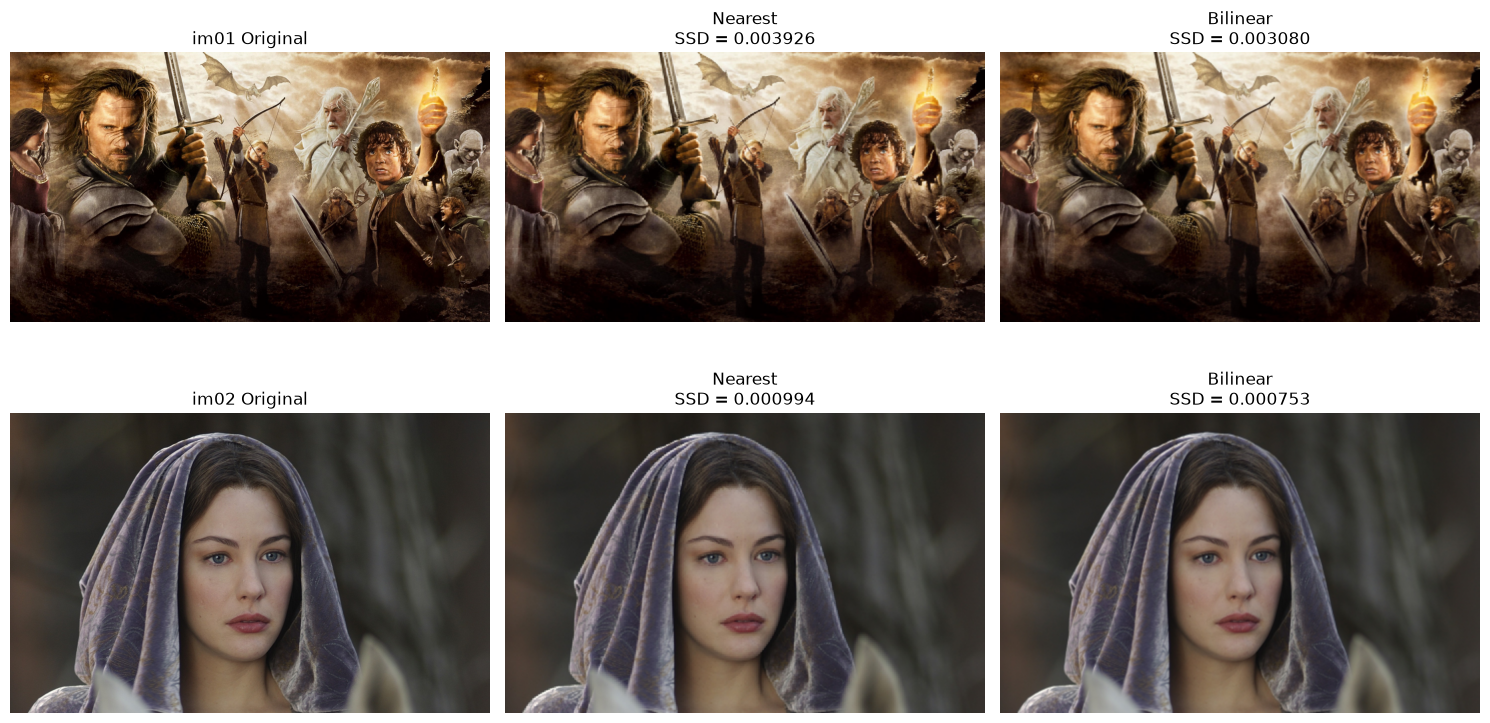

In [ ]:
# Display results
plt.figure(figsize=(15, 8))
plt.subplot(2, 3, 1)
plt.imshow(cv.cvtColor(im01, cv.COLOR_BGR2RGB))
plt.title("im01 Original")
plt.axis("off")
plt.subplot(2, 3, 2)
plt.imshow(cv.cvtColor(im01_nearest, cv.COLOR_BGR2RGB))
plt.title(f"Nearest\nSSD = {ssd_im01_nearest:.6f}")
plt.axis("off")
plt.subplot(2, 3, 3)
plt.imshow(cv.cvtColor(im01_bilinear, cv.COLOR_BGR2RGB))
plt.title(f"Bilinear\nSSD = {ssd_im01_bilinear:.6f}")
plt.axis("off")
plt.subplot(2, 3, 4)
plt.imshow(cv.cvtColor(im02, cv.COLOR_BGR2RGB))
plt.title("im02 Original")
plt.axis("off")
plt.subplot(2, 3, 5)
plt.imshow(cv.cvtColor(im02_nearest, cv.COLOR_BGR2RGB))
plt.title(f"Nearest\nSSD = {ssd_im02_nearest:.6f}")
plt.axis("off")
plt.subplot(2, 3, 6)
plt.imshow(cv.cvtColor(im02_bilinear, cv.COLOR_BGR2RGB))
plt.title(f"Bilinear\nSSD = {ssd_im02_bilinear:.6f}")
plt.axis("off")
plt.tight_layout()
plt.show()

Question 9


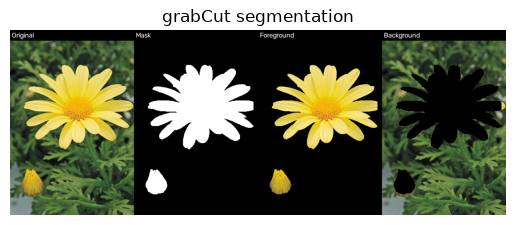

In [211]:
img_8 = cv.imread('image_8.png')
h, w = img_8.shape[:2]
# ---------- (a) GrabCut segmentation ----------
mask = np.zeros((h, w), np.uint8)
bgdModel = np.zeros((1, 65), np.float64)
fgdModel = np.zeros((1, 65), np.float64)
# initial rectangle roughly enclosing the flower (leave a small margin from the borders)
rect = (5, 5, w - 15, h - 10)
cv.grabCut(img_8, mask, rect, bgdModel, fgdModel, iterCount=5, mode=cv.GC_INIT_WITH_RECT)
# refine slightly: mark obvious sure-background corners implicitly handled by rect init
# final binary mask: 1 where probable/definite foreground
mask2 = np.where((mask == cv.GC_FGD) | (mask == cv.GC_PR_FGD), 1, 0).astype('uint8')
foreground = img_8 * mask2[:, :, np.newaxis]
background = img_8 * (1 - mask2[:, :, np.newaxis])

mask_vis = (mask2 * 255).astype('uint8')
# a combined figure for (a)
def label(im, text):
    im = im.copy()
    cv.rectangle(im, (0, 0), (im.shape[1], 22), (0, 0, 0), -1)
    cv.putText(im, text, (4, 16), cv.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1, cv.LINE_AA)
    return im

mask_bgr = cv.cvtColor(mask_vis, cv.COLOR_GRAY2BGR)
row_a = np.hstack([
    label(img_8, 'Original'),
    label(mask_bgr, 'Mask'),
    label(foreground, 'Foreground'),
    label(background, 'Background'),
])

plt.imshow(cv.cvtColor(row_a, cv.COLOR_BGR2RGB))
plt.title("grabCut segmentation")
plt.axis('off')
plt.show()

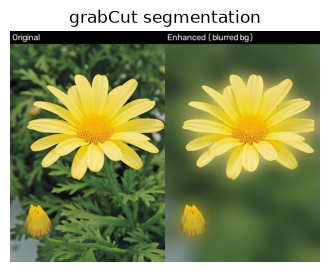

In [173]:
# ---------- (b) Background blur enhancement ----------
# heavily blur the whole image
blurred = cv.GaussianBlur(img_8, (0, 0), sigmaX=15, sigmaY=15)

mask3 = mask2[:, :, np.newaxis].astype(np.float32)
enhanced = (img_8.astype(np.float32) * mask3 + blurred.astype(np.float32) * (1 - mask3)).astype(np.uint8)

row_b = np.hstack([
    label(img_8, 'Original'),
    label(enhanced, 'Enhanced (blurred bg)'),
])
plt.figure(figsize=(4,3))
plt.imshow(cv.cvtColor(row_b, cv.COLOR_BGR2RGB))
plt.title("grabCut segmentation")
plt.axis('off')
plt.show()

In the original photo, the leaves/greenery immediately behind and below the petals are naturally in shadow. The flower itself blocks light from reaching that narrow strip, so it's darker there than the sunlit greenery further away, even before any processing.

When Gaussian-blur the whole image and then swap in the blurred pixels for the background region, each blurred background pixel is an average over a neighborhood in the original image. For a background pixel sitting just outside the flower's silhouette, that neighborhood is dominated by other nearby dark, shadowed pixels (not the bright, sunlit background further away, since it's outside the blur kernel's radius). So instead of averaging toward something brighter, it stays dark  and the shadow actually gets smeared over a wider band than in the original, since blurring diffuses it into adjacent pixels too.

Net effect: a visible dark ring hugging the flower's silhouette, transitioning to the brighter blurred bokeh only farther out. It's a real optical effect (the pre-existing shadow) made more visually obvious by the blur diffusing it outward, rather than an artifact of the mask itself.

Question 10

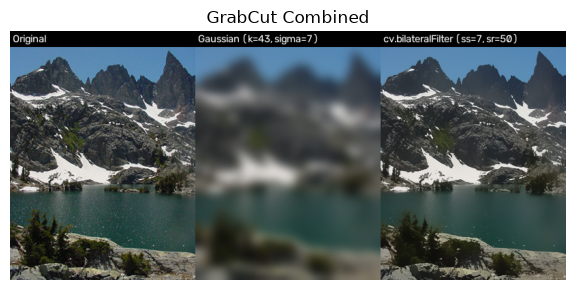

In [176]:
img_10 = cv.imread('image_10.png')
H, W = img_10.shape[:2]
 
# chosen parameters
sigma_s = 7      # spatial sigma
sigma_r = 50     # range (intensity/color) sigma
radius = int(np.ceil(3 * sigma_s))
d = 2 * radius + 1   # matching diameter for OpenCV's filter
def label(im, text):
    im = im.copy()
    cv.rectangle(im, (0, 0), (im.shape[1], 22), (0, 0, 0), -1)
    cv.putText(im, text, (4, 16), cv.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1, cv.LINE_AA)
    return im

# (a) OpenCV bilateralFilter vs Gaussian blur (similar kernel)

gaussian = cv.GaussianBlur(img_10, (d, d), sigmaX=sigma_s, sigmaY=sigma_s)
bilateral_cv = cv.bilateralFilter(img_10, d=d, sigmaColor=sigma_r, sigmaSpace=sigma_s)
 
row_a = np.hstack([
    label(img_10, 'Original'),
    label(gaussian, f'Gaussian (k={d}, sigma={sigma_s})'),
    label(bilateral_cv, f'cv.bilateralFilter (ss={sigma_s}, sr={sigma_r})'),
])

#plotting
plt.figure(figsize=(15, 3))
plt.imshow(cv.cvtColor(row_a, cv.COLOR_BGR2RGB))
plt.title("GrabCut Combined")
plt.axis('off')
plt.tight_layout()
plt.show()

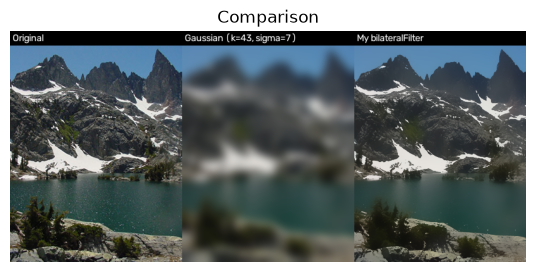

In [178]:
 #(b) Custom bilateral filter implementation
def my_bilateral_filter(image, sigma_s, sigma_r):
    image = image.astype(np.float32)
    Hh, Ww, C = image.shape
    r = int(np.ceil(3 * sigma_s))
    padded = cv.copyMakeBorder(image, r, r, r, r, cv.BORDER_REFLECT)
 
    accum = np.zeros_like(image)
    weight_sum = np.zeros((Hh, Ww, 1), dtype=np.float32)
 
    for dy in range(-r, r + 1):
        for dx in range(-r, r + 1):
            spatial_w = np.exp(-(dx ** 2 + dy ** 2) / (2.0 * sigma_s ** 2))
            shifted = padded[r + dy: r + dy + Hh, r + dx: r + dx + Ww]
            diff = shifted - image
            color_dist2 = np.sum(diff ** 2, axis=2, keepdims=True)
            range_w = np.exp(-color_dist2 / (2.0 * sigma_r ** 2))
            w = spatial_w * range_w
            accum += shifted * w
            weight_sum += w
 
    result = accum / weight_sum
    return np.clip(result, 0, 255).astype(np.uint8)
 
 
t0 = time.time()
bilateral_mine = my_bilateral_filter(img_10, sigma_s, sigma_r)
t_mine = time.time() - t0
 
t0 = time.time()
_ = cv.bilateralFilter(img_10, d=d, sigmaColor=sigma_r, sigmaSpace=sigma_s)
t_cv = time.time() - t0
 
row_b = np.hstack([
    label(img_10, 'Original'),
    label(gaussian, f'Gaussian (k={d}, sigma={sigma_s})'),
    label(bilateral_mine, 'My bilateralFilter'),
])
plt.figure(figsize=(15, 3))
plt.imshow(cv.cvtColor(row_b, cv.COLOR_BGR2RGB))
plt.title("Comparison")
plt.axis('off')
plt.show()

In [68]:
# Quantitative comparison
gray_cv = cv.cvtColor(bilateral_cv, cv.COLOR_BGR2GRAY)
gray_mine = cv.cvtColor(bilateral_mine, cv.COLOR_BGR2GRAY)
 
psnr_val = psnr(bilateral_cv, bilateral_mine, data_range=255)
ssim_val = ssim(gray_cv, gray_mine, data_range=255)
mae = np.mean(np.abs(bilateral_cv.astype(np.float32) - bilateral_mine.astype(np.float32)))
max_diff = np.max(np.abs(bilateral_cv.astype(np.int16) - bilateral_mine.astype(np.int16)))
 
# edge preservation check: gradient energy retained relative to original
def gradient_energy(im):
    g = cv.cvtColor(im, cv.COLOR_BGR2GRAY).astype(np.float32)
    gx = cv.Sobel(g, cv.CV_32F, 1, 0, ksize=3)
    gy = cv.Sobel(g, cv.CV_32F, 0, 1, ksize=3)
    return np.mean(np.sqrt(gx ** 2 + gy ** 2))
 
e_orig = gradient_energy(img_10)
e_gauss = gradient_energy(gaussian)
e_bil_cv = gradient_energy(bilateral_cv)
e_bil_mine = gradient_energy(bilateral_mine)
 
print(f"Kernel diameter d = {d}, sigma_s = {sigma_s}, sigma_r = {sigma_r}")
print(f"Runtime: mine = {t_mine:.3f}s, OpenCV = {t_cv:.4f}s")
print()
print("--- My implementation vs OpenCV's bilateralFilter ---")
print(f"PSNR : {psnr_val:.2f} dB")
print(f"SSIM : {ssim_val:.4f}")
print(f"MAE  : {mae:.3f} (grey levels)")
print(f"Max abs diff : {max_diff}")
print()
print("--- Edge (gradient) energy retained, relative to original ---")
print(f"Original            : {e_orig:.2f} (100.0%)")
print(f"Gaussian blur       : {e_gauss:.2f} ({100*e_gauss/e_orig:.1f}%)")
print(f"cv.bilateralFilter : {e_bil_cv:.2f} ({100*e_bil_cv/e_orig:.1f}%)")
print(f"My bilateralFilter  : {e_bil_mine:.2f} ({100*e_bil_mine/e_orig:.1f}%)")

Kernel diameter d = 43, sigma_s = 7, sigma_r = 50
Runtime: mine = 10.628s, OpenCV = 0.4135s

--- My implementation vs OpenCV's bilateralFilter ---
PSNR : 35.52 dB
SSIM : 0.9695
MAE  : 2.716 (grey levels)
Max abs diff : 49

--- Edge (gradient) energy retained, relative to original ---
Original            : 90.73 (100.0%)
Gaussian blur       : 13.98 (15.4%)
cv.bilateralFilter : 70.01 (77.2%)
My bilateralFilter  : 57.82 (63.7%)
